# Spatial FFT colormaps of the velocity for a single run

Computes the single-sided FFT amplitude of `U(t)` and `V(t)` **at every grid
point** of one run (no ROI averaging) and forms `|FFT(U)| + |FFT(V)|` per point.
From that per-point spectrum it draws two spatial colormaps over the whole PIV
field:

1. the **peak amplitude at `f_lib`** -- `|FFT(U)|+|FFT(V)|` at the libration
   frequency (max within +/- `HALFWIDTH_BINS` bins);
2. the **band-averaged amplitude over `[FMIN, FMAX]`** -- the integral of
   `|FFT(U)|+|FFT(V)|` over the band divided by its width `FMAX-FMIN`, i.e. the
   mean velocity-fluctuation amplitude each point carries in that band.

`PIV_FILENAME` is a **local** constant (point it at a raw or band-passed
`.mat`); calibration and the ROI box come from the dataset's
`param_postProcessing.json`, and the velocity honours `VALIDATE_VELOCITY` via
`load_piv`. A `_bp<lo>-<hi>Hz` filename is tagged onto the output figures.

Each map is saved **twice**: raw (in m/s) and **normalized by the libration velocity scale `U0`** (`figure_filename(..., normalized=True)`). Only the non-normalized figure is shown inline in the notebook.

## 1. Imports

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import get_window
from matplotlib.colors import LogNorm
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable

%matplotlib widget

from piv_postprocessing_lib import (topography_arrangement, figure_filename, load_piv,
                        parse_run_name, read_acquisition_params, libration_velocity_scale,
                        read_paramPostprocessing)

## 2. User settings

In [2]:
# --- Mute switch -----------------------------------------------------------
import builtins
if not hasattr(builtins, "_piv_real_print"):
    builtins._piv_real_print = builtins.print
MUTE_PRINT = False
builtins.print = (lambda *a, **k: None) if MUTE_PRINT else builtins._piv_real_print

# ----------------------------------------------------------------------
# USER SETTINGS
# ----------------------------------------------------------------------

# Run folder holding the .mat and the acquisition log.
RUN_DIR = ('/Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/'
           'CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1')

# LOCAL PIV .mat filename -- NOT from param_postProcessing.json. Point it at a
# raw file or a band-passed one (..._bp<lo>-<hi>Hz.mat).
PIV_FILENAME = 'PIVlab_results_uncalibrated.mat'

# --- Band for the integral colormap [Hz] ----------------------------------
FMIN = 0.1
FMAX = 0.35

# --- Inertial-wave characteristic angles -----------------------------------
# Lines at +/- theta from the vertical with sin(theta) = f / (2 f_rot).
# Peak-at-f_lib map: one +/- theta pair for f = f_lib. Band-average map: one
# +/- theta pair per frequency in LIST_FREQ, each a different line style; the
# legend shows "f Hz (f/f_rot)". LIST_FREQ may be one value or several.
LIST_FREQ = 0.400  # [Hz]
N_LINES = 4              # lines per angle, equally spaced in x across the whole domain
SCALING_WIDTH_LINE = 0.7  # line-width scaling for the +/- theta angle lines

# --- Options --------------------------------------------------------------
HALFWIDTH_BINS = 2       # peak-at-flib map = max over +/- this many FFT bins
FFT_WINDOW  = "hann"     # taper before the FFT ("boxcar"/None -> none)
FFT_DETREND = "constant" # "constant" removes each point's time-mean; None keeps it
CMAP = "viridis"
LOGC = False             # log colour scale on the colormaps (False -> linear)
SHOW_ROI_BOX = True      # overlay the ROI rectangle from PTS_ROI
FIG_FORMAT = 'png'
SAVE = True

# ----------------------------------------------------------------------
# Calibration / ROI / log name from the dataset's param file (RUN_DIR's parent).
_P = read_paramPostprocessing(os.path.dirname(RUN_DIR.rstrip('/')))
k0 = _P.k0
TOP_TOPO, BOTTOM_TOPO = topography_arrangement(RUN_DIR)
XSCALE, YSCALE = _P.XSCALE, _P.YSCALE
PTS_ROI = _P.PTS_ROI
LOG_FILENAME = _P.LOG_FILENAME
UNCAL_SCALE = _P.UNCAL_SCALE

## 3. Per-point FFT: |FFT(U)| + |FFT(V)|

In [3]:
def _interp_nan_time(A2):
    """Linearly interpolate NaNs along time for each row (grid point) of A2
    (npoints, nframes). Rows that are entirely NaN are left NaN (they map to
    blank cells in the colormap)."""
    A2 = A2.astype(float, copy=True)
    n = A2.shape[1]
    idx = np.arange(n)
    for i in range(A2.shape[0]):
        row = A2[i]
        m = np.isnan(row)
        if m.all():
            continue
        if m.any():
            row[m] = np.interp(idx[m], idx[~m], row[~m])
    return A2


def amp_spectrum_pt(A, fps, window=FFT_WINDOW, detrend=FFT_DETREND):
    """Per-point single-sided FFT amplitude spectrum of A (ny, nx, nframes).

    Returns (freq, amp) with amp shape (ny, nx, nfreq): |rfft|/coherent-gain,
    doubled off DC/Nyquist, per grid point (NOT averaged). All-NaN points stay
    NaN. The mean is removed first when detrend == 'constant'."""
    ny, nx, nt = A.shape
    A2 = _interp_nan_time(A.reshape(-1, nt))
    if detrend == "constant":
        A2 = A2 - np.nanmean(A2, axis=-1, keepdims=True)
    w = get_window(window, nt) if (window and window != "boxcar") else np.ones(nt)
    cg = w.sum()
    amp = np.abs(np.fft.rfft(A2 * w, axis=-1)) / cg
    if amp.shape[-1] > 1:
        amp[..., 1:] *= 2.0
        if nt % 2 == 0:
            amp[..., -1] /= 2.0
    freq = np.fft.rfftfreq(nt, d=1.0 / fps)
    return freq, amp.reshape(ny, nx, -1)


name = os.path.basename(RUN_DIR.rstrip("/"))
piv_file = os.path.join(RUN_DIR, PIV_FILENAME)
if not os.path.isfile(piv_file):
    raise FileNotFoundError("no %s in %s" % (PIV_FILENAME, RUN_DIR))

dt_vel, fps, ok = read_acquisition_params(os.path.join(RUN_DIR, LOG_FILENAME))
if ok:
    xscale, yscale = XSCALE, YSCALE
else:
    print("[warn] calibration not possible -- axes in px, velocity in px/frame")
    xscale = yscale = UNCAL_SCALE

X, Y, U, V, nframes = load_piv(piv_file)     # honours VALIDATE_VELOCITY, z up
x = xscale * X
z = yscale * Y
U = xscale * U / dt_vel
V = yscale * V / dt_vel

# Per-point amplitude spectra and their sum |FFT(U)| + |FFT(V)|.
freq, amp_u = amp_spectrum_pt(U, fps)
_, amp_v = amp_spectrum_pt(V, fps)
amp_total = amp_u + amp_v                     # (ny, nx, nfreq)

frot, flib, dphi = parse_run_name(name)
U0 = libration_velocity_scale(flib, dphi) if (flib and np.isfinite(dphi)) else np.nan
_bpm = re.search(r"_bp[-0-9.]+Hz", PIV_FILENAME)
BP_TAG = _bpm.group(0) if _bpm else ""
print("run   : %s   grid %d x %d   frames %d   fps %.4g Hz"
      % (name, x.shape[0], x.shape[1], nframes, fps))
print("flib  : %s   df = %.4g Hz   Nyquist = %.4g Hz   BP_TAG=%r"
      % ("%g Hz" % flib if flib else "unknown", freq[1] - freq[0], freq[-1], BP_TAG))
print("U0    : %.4g m/s  (libration velocity scale)" % U0)

run   : frot0.50Hz_flib0.400Hz_dphi2deg_SS1   grid 75 x 120   frames 1500   fps 25 Hz
flib  : 0.4 Hz   df = 0.01667 Hz   Nyquist = 12.5 Hz   BP_TAG=''
U0    : 0.01211 m/s  (libration velocity scale)


## 4. Colormap builders (`_colormap`, `_angle_lines`)

In [4]:
out_dir = os.path.join(RUN_DIR, "PostProcessing")
os.makedirs(out_dir, exist_ok=True)
_trapz = getattr(np, "trapezoid", np.trapz)   # np.trapz is deprecated in numpy>=2.0


def _angle_lines(axm, angle_freqs):
    """Overlay, on map axis `axm`, +/- theta inertial-wave lines for each
    frequency in `angle_freqs`, where sin(theta) = f/(2 f_rot) (theta measured
    from the vertical z direction). For each frequency and each sign, `N_LINES`
    parallel lines are drawn, equally spaced in x across the whole domain and
    anchored at the field mid-height (N_LINES=1 -> a single centred +/- pair).
    Each frequency gets a different line style; the line width is
    1.5 * SCALING_WIDTH_LINE. The legend labels each frequency "f Hz (f/f_rot)".
    `angle_freqs` may be a single number or a sequence of them.
    Frequencies with f/(2 f_rot) > 1 have no real angle and are skipped."""
    if angle_freqs is None:
        return
    # Accept a bare scalar (e.g. LIST_FREQ = 0.4) as well as a sequence.
    freqs = (list(angle_freqs)
             if isinstance(angle_freqs, (list, tuple, np.ndarray))
             else [angle_freqs])
    if len(freqs) == 0:
        return
    xl, zl = axm.get_xlim(), axm.get_ylim()
    xc = 0.5 * (xl[0] + xl[1]); zc = 0.5 * (zl[0] + zl[1])
    zz = np.array(zl)
    n = max(1, int(N_LINES))
    x0s = np.array([xc]) if n == 1 else np.linspace(xl[0], xl[1], n)
    lw = 1.5 * float(SCALING_WIDTH_LINE)
    styles = ["--", "-.", ":", "-"]   # first (default) style is dashed
    drew = False
    for i, f in enumerate(freqs):
        if not (frot and np.isfinite(frot) and f is not None and np.isfinite(f)):
            continue
        r = abs(f) / (2.0 * frot)
        if r > 1.0:
            print("  (f=%g Hz: f/(2 f_rot)=%.3g > 1 -- no real angle)" % (f, r))
            continue
        slope = np.tan(np.arcsin(r))                # dx/dz for this angle
        ls = styles[i % len(styles)]
        lab = r"%g Hz ($f/f_{\mathrm{rot}}$=%.2g)" % (f, f / frot)
        labeled = False
        for x0 in x0s:
            for sgn in (+1.0, -1.0):               # +theta and -theta
                axm.plot(x0 + sgn * slope * (zz - zc), zz, ls, color="w", lw=lw,
                         label=(None if labeled else lab))
                labeled = True
        drew = True
    axm.set_xlim(xl); axm.set_ylim(zl)              # keep the map extent
    if drew:
        leg = axm.legend(loc="upper right", fontsize=7)
        leg.get_frame().set_facecolor("0.25"); leg.get_frame().set_alpha(0.7)
        for _t in leg.get_texts():
            _t.set_color("w")


def _colormap(field, title, quantity, stem, angle_freqs=None):
    """Spatial colormap of `field` over (x, z) + a right-hand marginal of the
    field summed over all x, versus z (same height, shared z axis).

    Two figures are produced: RAW (m/s) and NORMALIZED (/U0). Only the raw one is
    shown in the notebook; the normalized one is saved but closed. The marginal
    and colorbar are appended with make_axes_locatable, so they exactly match the
    map's box height. `angle_freqs` overlays +/- theta inertial-wave lines
    (sin(theta) = f/(2 f_rot)) for each listed frequency.
    """
    if not np.any(np.isfinite(field)):
        print("  (all-NaN field -- %s skipped)" % stem); return
    _u_raw = r"$\mathrm{m\,s^{-1}}$" if ok else "px/frame"
    for normalize in (False, True):
        if normalize and not SAVE:
            continue                                   # normalized is save-only
        if normalize and not (np.isfinite(U0) and U0):
            print("  (U0 unknown -- normalized %s skipped)" % stem); continue
        fld = field / U0 if normalize else field
        _unit = r"$/\,U_0$" if normalize else r"(%s)" % _u_raw
        finite = fld[np.isfinite(fld)]
        if LOGC:
            pos = finite[finite > 0]
            vmin = np.nanpercentile(pos, 5) if pos.size else None
            vmax = np.nanpercentile(finite, 99.5)
            norm = LogNorm(vmin=vmin, vmax=vmax) if (vmin and vmin > 0) else None
            vkw = {} if norm else {"vmin": 0.0, "vmax": vmax}
        else:
            norm = None
            vkw = {"vmin": 0.0, "vmax": float(np.nanpercentile(finite, 99))}

        fig, axm = plt.subplots(figsize=(8.5, 4.8), dpi=150)
        pcm = axm.pcolormesh(x, z, np.ma.masked_invalid(fld), cmap=CMAP,
                             shading="nearest", norm=norm, **vkw)
        if SHOW_ROI_BOX and PTS_ROI is not None:
            (xa, za), (xb, zb) = PTS_ROI
            axm.add_patch(Rectangle((min(xa, xb), min(za, zb)), abs(xb - xa),
                                    abs(zb - za), fill=False, ec="red", lw=1.2))
        axm.set_aspect("equal")
        _u = "m" if ok else "px"
        axm.set_xlabel("x [%s]" % _u)
        axm.set_ylabel("z [%s]" % _u)
        _angle_lines(axm, angle_freqs)   # +/- theta inertial-wave lines

        # Right marginal + colorbar, appended so both match the map's box height.
        div = make_axes_locatable(axm)
        axp = div.append_axes("right", size="26%", pad=0.15, sharey=axm)
        axp.plot(np.nanmean(fld, axis=1), np.nanmean(z, axis=1), color="C3", lw=1.3)
        axp.set_xlabel(r"$\langle\cdot\rangle_x$  %s" % _unit)
        axp.grid(True, alpha=0.3)
        axp.tick_params(labelleft=False)              # z labels stay on the map
        cax = div.append_axes("right", size="4%", pad=0.15)
        fig.colorbar(pcm, cax=cax).set_label(r"%s  %s" % (quantity, _unit))

        fig.suptitle("%s\n%s%s   ($k_0=%g$, top=%s, bottom=%s)%s"
                     % (name, title, "   (normalized)" if normalize else "", k0,
                        TOP_TOPO, BOTTOM_TOPO,
                        ("   %s" % BP_TAG) if BP_TAG else ""), fontsize=10)
        if SAVE:
            out = figure_filename(os.path.join(out_dir, stem + BP_TAG), FIG_FORMAT,
                                  normalized=normalize)
            fig.savefig(out, dpi=200, bbox_inches="tight")
            print("Figure written to:\n  %s" % out)
        if normalize:
            plt.close(fig)        # normalized: saved but not shown
        else:
            plt.show()            # non-normalized: shown in the notebook



## 5. Figures

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1/PostProcessing/VelocityFFT_spatialmap_peak_flib.png


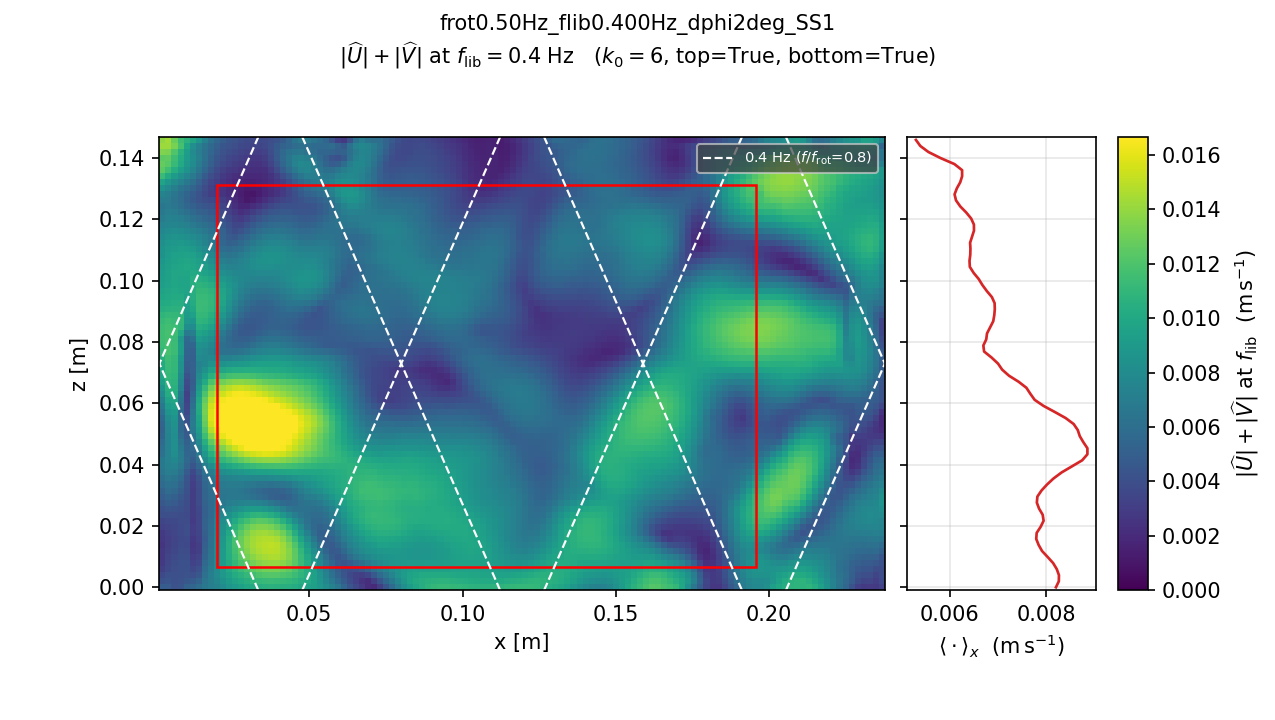

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1/PostProcessing/VelocityFFT_spatialmap_peak_flib_normalized.png
Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1/PostProcessing/VelocityFFT_spatialmap_bandavg_0.1-0.35Hz.png


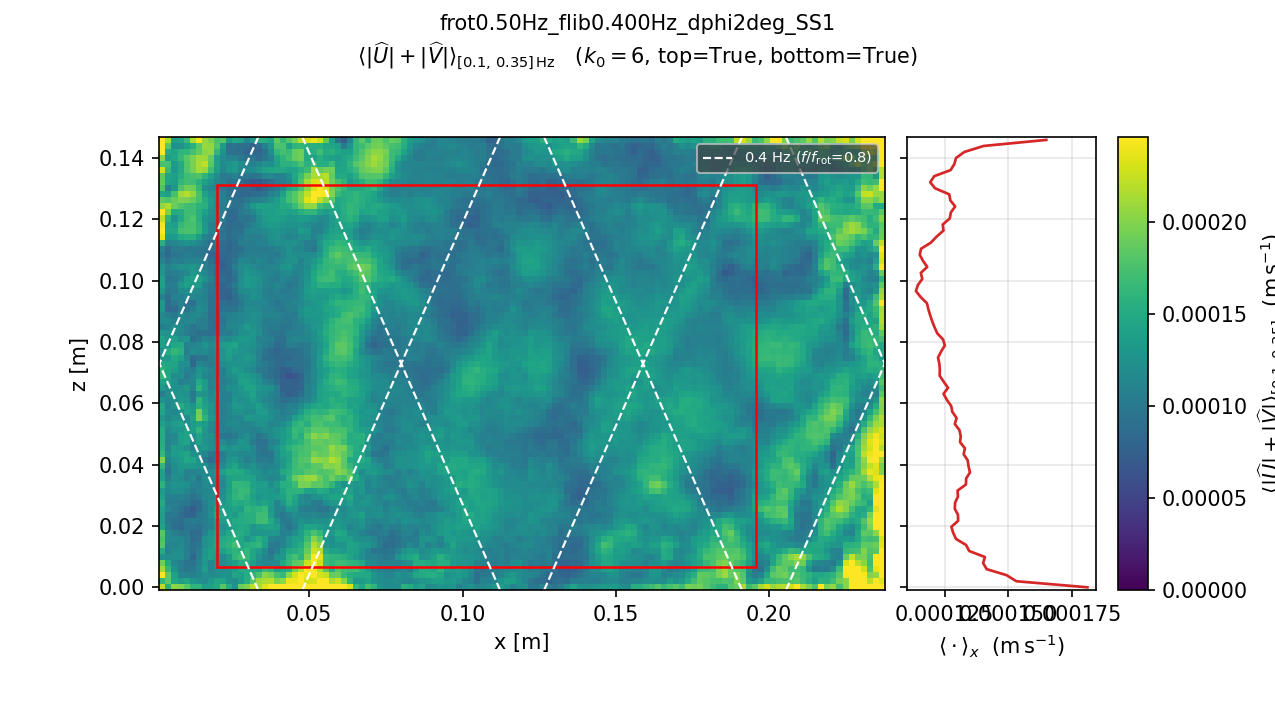

Figure written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1/PostProcessing/VelocityFFT_spatialmap_bandavg_0.1-0.35Hz_normalized.png
Depth profiles written to:
  /Users/jeromenoir/Documents/MyDocuments/LOCAL_PROJECT/TOPOGRAPHY_LIBRATION/CylinderExperimentsGMA/k6_TopBottom/frot0.50Hz_flib0.400Hz_dphi2deg_SS1/PostProcessing/depthProfile_FFT.npz


In [5]:

# (1) Peak amplitude at f_lib: max over +/- HALFWIDTH_BINS bins around f_lib.
if not (flib and np.isfinite(flib)):
    print("[skip] f_lib unknown from the run name -- peak-at-flib map skipped")
else:
    _k = int(np.argmin(np.abs(freq - flib)))
    _lo = max(0, _k - HALFWIDTH_BINS)
    _hi = min(freq.size, _k + HALFWIDTH_BINS + 1)
    peak_flib = np.max(amp_total[:, :, _lo:_hi], axis=2)   # NaN where point all-NaN
    _prof_flib = np.nanmean(peak_flib, axis=1)             # x-averaged, vs z
    _colormap(peak_flib,
              r"$|\widehat{U}|+|\widehat{V}|$ at $f_{\mathrm{lib}}=%.4g$ Hz" % flib,
              r"$|\widehat{U}|+|\widehat{V}|$ at $f_{\mathrm{lib}}$",
              "VelocityFFT_spatialmap_peak_flib",
              angle_freqs=(flib,))   # +/- theta lines for f_lib

# (2) Band-AVERAGED amplitude over [FMIN, FMAX]: the integral of
# |FFT(U)|+|FFT(V)| divided by the bandwidth (FMAX - FMIN), i.e. the mean
# amplitude in the band (same units as the field, m/s).
_band = (freq >= FMIN) & (freq <= FMAX)
if _band.sum() < 2 or not (FMAX > FMIN):
    print("[skip] band [%.4g, %.4g] Hz invalid (need FMAX > FMIN and >= 2 bins) "
          "-- band-average map skipped" % (FMIN, FMAX))
else:
    bandavg = _trapz(amp_total[:, :, _band], freq[_band], axis=2) / (FMAX - FMIN)
    _prof_band = np.nanmean(bandavg, axis=1)               # x-averaged, vs z
    _colormap(bandavg,
              r"$\langle|\widehat{U}|+|\widehat{V}|\rangle_{[%.3g,\,%.3g]\,\mathrm{Hz}}$"
              % (FMIN, FMAX),
              r"$\langle|\widehat{U}|+|\widehat{V}|\rangle_{[%.3g,%.3g]}$" % (FMIN, FMAX),
              "VelocityFFT_spatialmap_bandavg_%.3g-%.3gHz" % (FMIN, FMAX),
              angle_freqs=LIST_FREQ)   # +/- theta lines for each f in LIST_FREQ

# --- Save the x-averaged depth profiles (both f_lib and the band) ----------
# Same quantities as drawn in the right-hand marginals, stored next to the
# figures. Raw (m/s) and normalized (/U0) versions of each are kept.
if SAVE:
    _u0ok = bool(np.isfinite(U0) and U0)
    _out = {"z": np.nanmean(z, axis=1), "U0": U0,
            "flib": (flib if flib else np.nan), "FMIN": FMIN, "FMAX": FMAX,
            "bp_tag": BP_TAG}
    for _key, _pr in (("flib", locals().get("_prof_flib")),
                      ("band", locals().get("_prof_band"))):
        if _pr is None:
            continue
        _out["profile_" + _key] = _pr
        _out["profile_" + _key + "_normalized"] = (
            _pr / U0 if _u0ok else np.full_like(_pr, np.nan))
    if any(k.startswith("profile_") for k in _out):
        _npz = os.path.join(out_dir, "depthProfile_FFT" + BP_TAG + ".npz")
        np.savez(_npz, **_out)
        print("Depth profiles written to:\n  %s" % _npz)
